# 02 · Title embeddings and job families

**Input:** `jobs_model.parquet` (from 01).

**Output:** `title_features.parquet`, one row per unique `title_clean`, with:
- `title_pca_0..31`: a 32-dim PCA of the sentence embedding. These are features for the salary, survival and causal models.
- `title_cluster` + `cluster_label`: data-driven job families, for charts, heterogeneity analysis and explanations.

Downstream notebooks join this on `title_clean`. Embeddings are cached in `title_emb.npy`, so reruns skip the slow step.

**Method:**
1. Expand job-title shorthand (rn → registered nurse, sr → senior, …).
2. Embed each **unique** title once with `all-MiniLM-L6-v2` (normalized, 384-d).
3. Reduce with PCA to 32 dims, and cluster with MiniBatchKMeans into `N_CLUSTERS` families.

If `sentence-transformers` is unavailable, it falls back to TF-IDF (char 3–5-grams) + SVD.

In [1]:
import sys, time
from pathlib import Path

ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from src import features as F

cfg = F.get_config()
SAMPLE_FRAC = cfg['SAMPLE_FRAC']      # set < 1.0 for a quick trial run (e.g. 0.05)
FORCE_REBUILD = cfg['FORCE_REBUILD']  # True = ignore cached outputs and recompute
SUFFIX = F.sample_suffix(cfg)
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 180)
print('root:', ROOT, '| SAMPLE_FRAC:', SAMPLE_FRAC, '| FORCE_REBUILD:', FORCE_REBUILD)

root: /home/jovyan/DataDive26 | SAMPLE_FRAC: 1.0 | FORCE_REBUILD: False


In [2]:
EMB_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'  # alternatives: 'BAAI/bge-small-en-v1.5', 'sentence-transformers/all-mpnet-base-v2' (better, ~5x slower)
N_PCA = 32
N_CLUSTERS = 120
N_CPU = F.cpu_limit()
print('usable CPUs:', N_CPU)

usable CPUs: 64


## 1. Unique titles

In [3]:
jobs = pd.read_parquet(cfg['DATA_PROC'] / f'jobs_model{SUFFIX}.parquet',
                       columns=['JOB_HASH', 'title_clean', 'city_clean', 'has_salary', 'log_pay', 'duration_days'])
titles = (jobs.groupby('title_clean', observed=True)
              .agg(n_jobs=('JOB_HASH', 'size'), disclosure_rate=('has_salary', 'mean'),
                   median_log_pay=('log_pay', 'median'))
              .reset_index().sort_values(['n_jobs', 'title_clean'], ascending=[False, True], ignore_index=True))
print(f'{len(jobs):,} jobs -> {len(titles):,} unique titles; top 100 titles cover {titles.n_jobs.head(100).sum()/len(jobs):.0%} of jobs')

1,279,291 jobs -> 319,641 unique titles; top 100 titles cover 16% of jobs


### Core title = the occupation only
Titles carry a lot of text that isn't the job: cities ("store manager - nashville tn"), pay and bonuses ("$3 500 sign-on bonus"), shift and schedule, req/store numbers. Left in, the embedding groups postings by *that* text. For example, pharmacists and CNAs end up together because both mention a sign-on bonus.

These details are already separate columns/flags in `jobs_model`, so here they're stripped before embedding:
- Place names come from the data (cities with enough postings, minus city names that are also ordinary words).
- Job shorthand is then expanded (rn → registered nurse).

In [4]:
city_counts = jobs['city_clean'].value_counts()
place_re = F.place_pattern([c for c, n in city_counts.items() if n >= max(3, 60 * SAMPLE_FRAC) and c != 'unknown'])
titles['core_title'] = F.core_title(titles['title_clean'], place_re)
titles['embed_text'] = F.expand_abbreviations(titles['core_title'])
print(f"unique: {titles['title_clean'].nunique():,} titles -> {titles['core_title'].nunique():,} core titles "
      f"-> {titles['embed_text'].nunique():,} texts to embed")
changed = titles[titles['embed_text'] != titles['title_clean']]
print(f'{len(changed):,} titles changed ({changed.n_jobs.sum()/len(jobs):.0%} of postings)')
changed[['title_clean', 'embed_text', 'n_jobs']].head(20)

unique: 319,641 titles -> 253,865 core titles -> 249,661 texts to embed
165,516 titles changed (40% of postings)


,title_clean,embed_text,n_jobs
5,certified nursing assistant cna,certified nursing assistant,3849
9,pharmacy technician / pharm tech apprenticeship,pharmacy technician / pharm apprenticeship,3265
17,licensed practical nurse lpn,licensed practical nurse,2836
29,lpn licensed practical nurse,licensed practical nurse,2137
31,courtesy clerk bagger - student,courtesy clerk bagger,2079
34,cashier - student,cashier,2030
41,pharmacy tech certified,pharmacy technician certified,1814
46,rn registered nurse,registered nurse,1717
49,registered nurse rn,registered nurse,1705
52,customer service associate - temporary,customer service associate,1611


## 2. Embed (cached)

In [5]:
emb_path = cfg['DATA_PROC'] / f'title_emb{SUFFIX}.npy'
emb_index_path = cfg['DATA_PROC'] / f'title_emb_index{SUFFIX}.parquet'

def embed_sentence_transformer(texts):
    import torch
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(N_CPU)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = SentenceTransformer(EMB_MODEL, device=device)
    return model.encode(texts, batch_size=512, show_progress_bar=True, normalize_embeddings=True,
                        convert_to_numpy=True).astype('float32')

def embed_tfidf(texts):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD
    from sklearn.preprocessing import normalize
    X = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, sublinear_tf=True).fit_transform(texts)
    Z = TruncatedSVD(n_components=128, random_state=cfg['RANDOM_STATE']).fit_transform(X)
    return normalize(Z).astype('float32')

texts = pd.Index(titles['embed_text'].unique())   # embed each distinct text once
cached = emb_path.exists() and emb_index_path.exists() and not FORCE_REBUILD
if cached:
    idx = pd.read_parquet(emb_index_path)
    cached = 'embed_text' in idx.columns and idx['embed_text'].tolist() == texts.tolist()
if cached:
    emb_u = np.load(emb_path)
    EMB_METHOD = idx['method'].iloc[0]
    print(f'loaded cached embeddings {emb_u.shape} ({EMB_METHOD})')
else:
    t0 = time.time()
    try:
        emb_u = embed_sentence_transformer(texts.tolist()); EMB_METHOD = EMB_MODEL
    except ImportError as e:
        print('sentence-transformers unavailable -> TF-IDF fallback:', e)
        emb_u = embed_tfidf(texts.tolist()); EMB_METHOD = 'tfidf-char-svd128'
    np.save(emb_path, emb_u)
    pd.DataFrame({'embed_text': texts, 'method': EMB_METHOD}).to_parquet(emb_index_path, index=False)
    print(f'embedded {emb_u.shape} with {EMB_METHOD} in {time.time()-t0:.0f}s')

emb = emb_u[texts.get_indexer(titles['embed_text'])]   # one row per title_clean, aligned with `titles`

loaded cached embeddings (249661, 384) (sentence-transformers/all-MiniLM-L6-v2)


In [6]:
# Sanity check: nearest neighbours of a few probe titles
def neighbours(query, k=8):
    i = titles.index[titles['title_clean'] == query]
    if len(i) == 0:
        return f'({query!r} not in titles)'
    sims = emb @ emb[i[0]]
    top = [j for j in np.argsort(-sims)[:k + 1] if j != i[0]][:k]
    return ', '.join(f"{titles.title_clean[j]} ({sims[j]:.2f})" for j in top)

for q in ['registered nurse', 'rn', 'line cook', 'software engineer', 'cdl a truck driver', 'cashier', 'pharmacy technician']:
    print(f'{q:>22} -> {neighbours(q)}')

      registered nurse -> registered nurse rn part time (1.00), rn 3rd shift $40/hour + $6 000 retention bonus (1.00), rn - $20 000 sign on bonus (1.00), registered nurse - murfreesboro prn rn (1.00), registered nurse - ft nights (1.00), registered nurse rn - prn day shift 7a-7p (1.00), registered nurse rn - prn nights (1.00), registered nurse rn - pt nights (1.00)
                    rn -> registered nurse rn part time (1.00), rn 3rd shift $40/hour + $6 000 retention bonus (1.00), rn - $20 000 sign on bonus (1.00), registered nurse - murfreesboro prn rn (1.00), registered nurse - ft nights (1.00), registered nurse rn - prn day shift 7a-7p (1.00), registered nurse rn - prn nights (1.00), registered nurse rn - pt nights (1.00)
             line cook -> line cook part-time (1.00), line cook part-time & full-time (1.00), line cook full-time (1.00), line cook - chattanooga tn (1.00), line cook - part time (1.00), line cook - ft + bonus available (1.00), line cook - ft (1.00), line cook par

## 3. PCA features

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=N_PCA, random_state=cfg['RANDOM_STATE'])
Z = pca.fit_transform(emb).astype('float32')
print(f'{N_PCA} components explain {pca.explained_variance_ratio_.sum():.1%} of embedding variance')
pca_cols = [f'title_pca_{i}' for i in range(N_PCA)]

32 components explain 49.6% of embedding variance


## 4. Job families (MiniBatchKMeans)
Clustering runs on the full normalized embedding (cosine geometry). Each title is weighted by how many postings use it, so common jobs get well-placed centroids.

The small k-sweep below reports how much of the variation in pay each granularity explains. Higher k always explains more, so look for the point of diminishing returns.

In [8]:
from sklearn.cluster import MiniBatchKMeans

def fit_kmeans(k):
    km = MiniBatchKMeans(n_clusters=k, random_state=cfg['RANDOM_STATE'], batch_size=8192, n_init=5, max_iter=200)
    km.fit(emb, sample_weight=titles['n_jobs'].to_numpy())
    return km

def pay_r2(labels):
    """Share of job-level log-pay variance explained by cluster means (salaried jobs only)."""
    lab = pd.Series(labels, index=titles['title_clean'].to_numpy())
    j = jobs.loc[jobs['log_pay'].notna(), ['title_clean', 'log_pay']].copy()
    j['c'] = j['title_clean'].map(lab)
    fitted = j.groupby('c')['log_pay'].transform('mean')
    return 1 - ((j['log_pay'] - fitted) ** 2).sum() / ((j['log_pay'] - j['log_pay'].mean()) ** 2).sum()

sweep = []
for k in [20, 40, 80, 150]:
    t0 = time.time()
    sweep.append({'k': k, 'pay_R2': round(pay_r2(fit_kmeans(k).labels_), 3), 'seconds': round(time.time() - t0, 1)})
pd.DataFrame(sweep)

,k,pay_R2,seconds
0,20,0.401,16.4
1,40,0.449,25.6
2,80,0.512,37.8
3,150,0.539,70.4


In [9]:
km = fit_kmeans(N_CLUSTERS)
titles['title_cluster'] = km.labels_.astype('int16')
print(f'pay R² explained by {N_CLUSTERS} clusters: {pay_r2(km.labels_):.3f}')

# Label each cluster by its three most frequent core titles (abbreviations expanded, weighted by postings).
labels = (titles.groupby(['title_cluster', 'embed_text'])['n_jobs'].sum().reset_index()
                .sort_values('n_jobs', ascending=False).groupby('title_cluster')['embed_text']
                .agg(lambda s: ' | '.join(s.head(3))).rename('cluster_label'))
titles = titles.merge(labels, left_on='title_cluster', right_index=True, how='left')

# Job-level cluster stats
jobs = jobs.merge(titles[['title_clean', 'title_cluster', 'cluster_label']], on='title_clean', how='left')
cluster_stats = (jobs.groupby(['title_cluster', 'cluster_label'])
                     .agg(n_jobs=('JOB_HASH', 'size'), n_titles=('title_clean', 'nunique'),
                          disclosure_rate=('has_salary', 'mean'), median_log_pay=('log_pay', 'median'),
                          median_duration=('duration_days', 'median'))
                     .reset_index().sort_values('n_jobs', ascending=False, ignore_index=True))
cluster_stats['median_pay'] = np.exp(cluster_stats.pop('median_log_pay')).round(-2)
cluster_stats.head(30)

pay R² explained by 120 clusters: 0.534


,title_cluster,cluster_label,n_jobs,n_titles,disclosure_rate,median_duration,median_pay
0,83,maintenance technician | automotive technician...,41712,9928,0.299626,27.668750,49900.0
1,22,salesperson | outside sales representative | s...,30019,5303,0.362137,25.779167,56000.0
2,16,assistant manager | assistant general manager ...,22610,1275,0.156524,16.616319,37400.0
3,38,delivery driver | driver | store driver,22355,1990,0.226034,15.127083,41600.0
4,103,customer service representative | customer ser...,21594,1925,0.377095,16.102778,33800.0
5,62,clin nurse iii | clin nurse ii | registered nu...,21304,8332,0.099747,28.390625,89500.0
6,3,cashier | cashier/sales associate - all shifts...,20869,817,0.445254,27.720833,26500.0
7,100,general manager | general manager in training ...,20765,3638,0.200193,20.695139,70900.0
8,84,account executive | account manager | relation...,19742,7894,0.275707,26.730903,81700.0
9,41,licensed practical nurse | licensed practical ...,19623,3063,0.163278,17.010417,59300.0


In [10]:
# Spot-check 10 clusters: are the titles inside them coherent?
rng = np.random.default_rng(cfg['RANDOM_STATE'])
for c in rng.choice(cluster_stats['title_cluster'].to_numpy(), size=min(10, N_CLUSTERS), replace=False):
    members = titles[titles['title_cluster'] == c]
    sample = members.sample(min(8, len(members)), random_state=0)['title_clean'].tolist()
    print(f'[{c}] {labels[c]}  ({len(members):,} titles)\n     random members: {sample}\n')

[89] lead sales associate- in | support lead | sales lead  (9,336 titles)
     random members: ['lead sales associate-ft in mcminnville tn s00121', 'lead engineer substation protection & control', 'housekeeping lead', 'oci delivery execution lead-director', 'lead director - performance analytics & optimization', 'lead product owner voice support', 'sales team lead- club & emerging value accounts', 'lead scientist- vakoc lab']

[107] caregiver | private caregiver | experienced caregiver  (533 titles)
     random members: ['caregiver memory care', 'caregiver for elderly - night shift', 'non - medical caregiver', 'memory care dayshift caregiver 7a-7p sob $750', 'kid s care - seasonal', 'caregiver for 3-hour shifts m-f', 'prn resident assistant- caregiver 1st shift 6am-2pm and 2nd shift 2pm-10pm', 'caregiver-prn']

[41] licensed practical nurse | licensed practical nurse agency free facility | licensed practical nurse - agency free facility  (3,063 titles)
     random members: ['lpn - murf

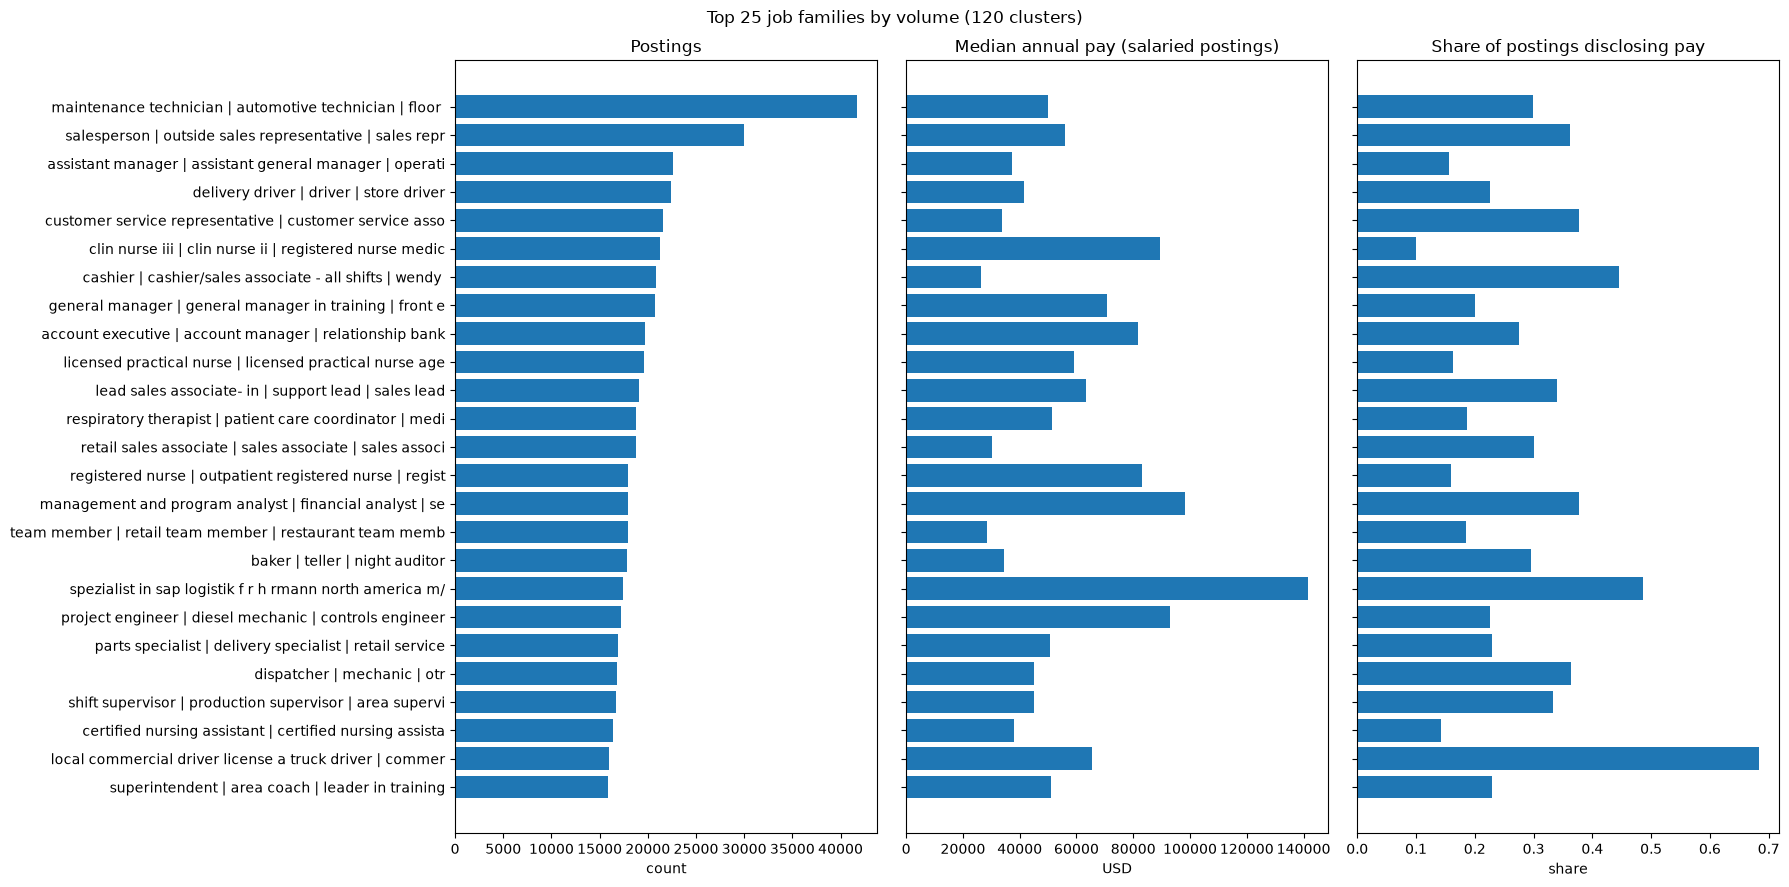

In [11]:
top = cluster_stats.head(25).iloc[::-1]
fig, axes = plt.subplots(1, 3, figsize=(18, 9), sharey=True)
names = top['cluster_label'].str.slice(0, 55)
axes[0].barh(names, top['n_jobs']); axes[0].set(title='Postings', xlabel='count')
axes[1].barh(names, top['median_pay']); axes[1].set(title='Median annual pay (salaried postings)', xlabel='USD')
axes[2].barh(names, top['disclosure_rate']); axes[2].set(title='Share of postings disclosing pay', xlabel='share')
plt.suptitle(f'Top 25 job families by volume ({N_CLUSTERS} clusters)')
plt.tight_layout(); fig.savefig(cfg['FIG_DIR'] / f'02_job_families{SUFFIX}.png', dpi=150); plt.show()

## 5. Save

In [12]:
out = titles[['title_clean', 'core_title', 'n_jobs', 'title_cluster', 'cluster_label']].copy()
out[pca_cols] = Z
out['emb_method'] = EMB_METHOD
out_path = cfg['DATA_PROC'] / f'title_features{SUFFIX}.parquet'
out.to_parquet(out_path, index=False)
cluster_stats.to_csv(cfg['DATA_PROC'] / f'cluster_stats{SUFFIX}.csv', index=False)
assert out['title_clean'].is_unique and set(out['title_clean']) >= set(jobs['title_clean'])
print(f'saved {out_path.name}: {out.shape}, {out_path.stat().st_size/1e6:.0f} MB  (method: {EMB_METHOD})')

saved title_features.parquet: (319641, 38), 63 MB  (method: sentence-transformers/all-MiniLM-L6-v2)
